#Взлом шифра Виженера (by Толстых Александра)


In [102]:
from collections import Counter
import matplotlib.pyplot as plt

Код шифровщика и дешифровщика из основной части лабораторной работы

In [103]:
def encrypt_vigenere(plaintext: str, keyword: str) -> str:
    """
    Encrypts plaintext using a Vigenere cipher.

    >>> encrypt_vigenere("PYTHON", "A")
    'PYTHON'
    >>> encrypt_vigenere("python", "a")
    'python'
    >>> encrypt_vigenere("ATTACKATDAWN", "LEMON")
    'LXFOPVEFRNHR'
    """

    lowercase_start = ord('a')
    uppercase_start = ord('A')
    alphabet_size = 26
    key_len = len(keyword)

    ciphertext = ""

    for i in range(len(plaintext)):
        char = plaintext[i]

        key_letter_ord = ord(keyword[i % key_len])
        if (key_letter_ord >= lowercase_start) and (key_letter_ord < lowercase_start + alphabet_size):
            shift = key_letter_ord - lowercase_start
        elif (key_letter_ord >= uppercase_start) and (key_letter_ord < uppercase_start + alphabet_size):
            shift = key_letter_ord - uppercase_start
        else:
            shift = 0

        if (ord(char) >= lowercase_start) and (ord(char) < lowercase_start + alphabet_size):
            new_char = chr((ord(char) - lowercase_start + shift) % alphabet_size + lowercase_start)
            ciphertext += new_char
        elif (ord(char) >= uppercase_start) and (ord(char) < uppercase_start + alphabet_size):
            new_char = chr((ord(char) - uppercase_start + shift) % alphabet_size + uppercase_start)
            ciphertext += new_char
        else:
            ciphertext += char

    return ciphertext


def decrypt_vigenere(ciphertext: str, keyword: str) -> str:
    """
    Decrypts a ciphertext using a Vigenere cipher.

    >>> decrypt_vigenere("PYTHON", "A")
    'PYTHON'
    >>> decrypt_vigenere("python", "a")
    'python'
    >>> decrypt_vigenere("LXFOPVEFRNHR", "LEMON")
    'ATTACKATDAWN'
    """
    lowercase_start = ord('a')
    uppercase_start = ord('A')
    alphabet_size = 26
    key_len = len(keyword)

    plaintext = ""

    for i in range(len(ciphertext)):
        char = ciphertext[i]

        key_letter_ord = ord(keyword[i % key_len])
        if (key_letter_ord >= lowercase_start) and (key_letter_ord < lowercase_start + alphabet_size):
            shift = key_letter_ord - lowercase_start
        elif (key_letter_ord >= uppercase_start) and (key_letter_ord < uppercase_start + alphabet_size):
            shift = key_letter_ord - uppercase_start
        else:
            shift = 0

        if (ord(char) >= lowercase_start) and (ord(char) < lowercase_start + alphabet_size):
            new_char = chr((ord(char) - lowercase_start - shift) % alphabet_size + lowercase_start)
            plaintext += new_char
        elif (ord(char) >= uppercase_start) and (ord(char) < uppercase_start + alphabet_size):
            new_char = chr((ord(char) - uppercase_start - shift) % alphabet_size + uppercase_start)
            plaintext += new_char
        else:
            plaintext += char

    return plaintext


###1. Прочтение исходного текста

Из исходного текста удаляем все символы, не являющиеся буквами

In [104]:
with open("cipher.txt", "r") as f:
    text = f.read()

text_len = len(text)
text

'“wfcehcqvy’cefscprr,mn.xlcyxaj!”:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnief\ntlct1.xysxqanvgjolhauxgtme\nhajaeidcazmgzfjehercprr!\nslwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajha’hafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.\nxgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpd—erklvtpskvhhvlwlap—poypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoy’pvwhptkezaszxsltwfmsf’drawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhprar’axspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxej—exohwrcewx!\nmsldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzi

###2. Частоты буквосочетаний

Текст имеет достаточно большой размер, чтобы предполагать, что повторяющиеся буквосочетания являются одними и теми же частями слов и словосочетаний

In [105]:
letter_3 = Counter([text[i:i+3] for i in range(text_len - 2)])
letter_4 = Counter([text[i:i+4] for i in range(text_len - 3)])
letter_5 = Counter([text[i:i+5] for i in range(text_len - 4)])
letter_6 = Counter([text[i:i+6] for i in range(text_len - 5)])

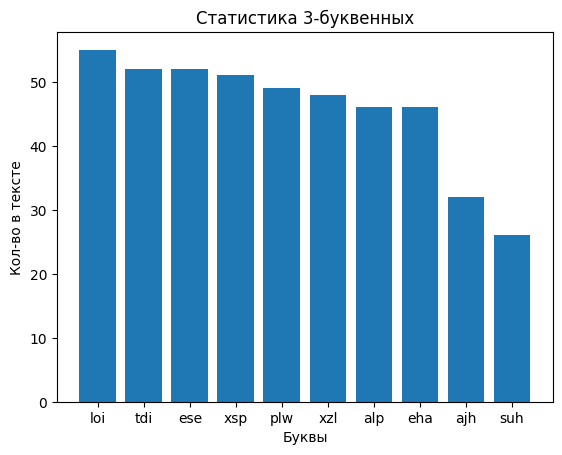

In [106]:
words = [letter_3.most_common(10)[i][0] for i in range(10)]
values = [letter_3.most_common(10)[i][1] for i in range(10)]

plt.bar(words, values)

plt.title("Статистика 3-буквенных")
plt.xlabel("Буквы")
plt.ylabel("Кол-во в тексте")

plt.show()

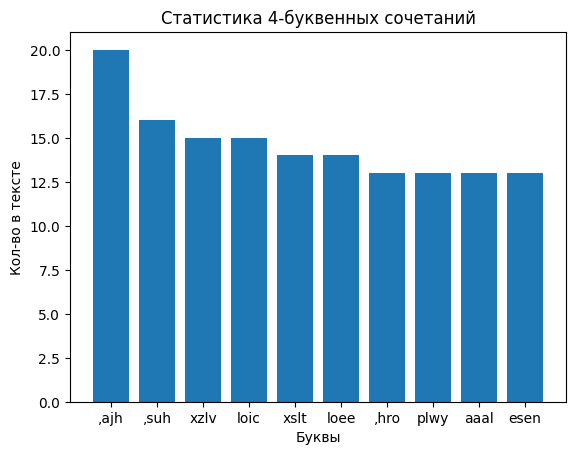

In [107]:
words = [letter_4.most_common(10)[i][0] for i in range(10)]
values = [letter_4.most_common(10)[i][1] for i in range(10)]

plt.bar(words, values)

plt.title("Статистика 4-буквенных сочетаний")
plt.xlabel("Буквы")
plt.ylabel("Кол-во в тексте")

plt.show()

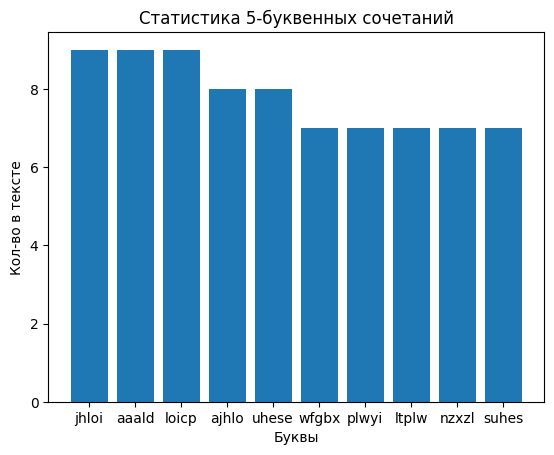

In [108]:
words = [letter_5.most_common(10)[i][0] for i in range(10)]
values = [letter_5.most_common(10)[i][1] for i in range(10)]

plt.bar(words, values)

plt.title("Статистика 5-буквенных сочетаний")
plt.xlabel("Буквы")
plt.ylabel("Кол-во в тексте")

plt.show()

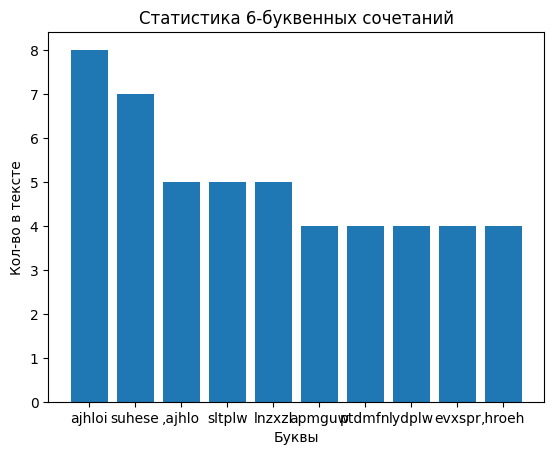

In [109]:
words = [letter_6.most_common(10)[i][0] for i in range(10)]
values = [letter_6.most_common(10)[i][1] for i in range(10)]

plt.bar(words, values)

plt.title("Статистика 6-буквенных сочетаний")
plt.xlabel("Буквы")
plt.ylabel("Кол-во в тексте")

plt.show()

###3. Анализ периода

Если предполагать, что повторяющиеся буквосочетания --- одни и те же части слов, то расстояния между такими буквосочетаниями должны делиться на длину ключа.

In [110]:
periods = []
substr_counter = letter_3.most_common(5) + letter_4.most_common(5) + letter_5.most_common(5) + letter_6.most_common(5)

In [111]:
for substr in [substr_counter[i][0] for i in range(len(substr_counter))]:
  indeces = []
  start = 0
  while True:
    start = text.find(substr, start)
    if start == -1:
      break
    indeces.append(start)
    start += 1
  for i in range(len(indeces) - 1):
    periods.append(indeces[i+1] - indeces[i])

Теперь найдем для каждой пары периодов GCD, и наиболее частовстречающееся значение и будет предположительной длиной ключа.

In [112]:
def gcd(a, b):
  a, b = max(a, b), min(a, b)
  while b > 0:
    a, b = b, a%b
  return a

In [113]:
gcd_counter = Counter()
for i in range(len(periods)):
  for j in range(i+1, len(periods)):
    gcd_counter[gcd(periods[i], periods[j])] += 1

gcd_counter.most_common(5)

[(8, 39337), (16, 11459), (24, 5742), (1, 4060), (2, 3292)]

In [114]:
key_len = gcd_counter.most_common(1)[0][0]
f"Предположительная длина ключа: {key_len}"

'Предположительная длина ключа: 8'

Из получившихся значений делаем предположение, что если ключ состоит из одного слова, то скорее всего он имеет длину 8.

###4. Непосредственно дешифровка

После того, как мы получили предположительную длину ключа, можно заняться частотным анализом для групп букв, полученных одним и тем же сдвигом ($text[i::8]$, $\, i = 1,\ldots, 8$). Будем отталкиваться от того, что в английском языке 3 самые частовстречающиеся буквы: $E$, $A$, $T$, а значит и самая частовстречающаяся буква в группе будет при расшифровке одной из этих.

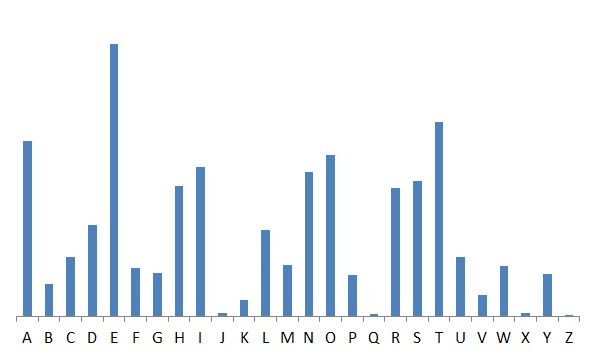

In [115]:
key = [[] for _ in range(key_len)]

# тут мы пользуемся тем, что сдвиг на ключ + получение ответа <=> сдвиг на ответ + получение ключа
for i in range(key_len):
  key[i].append(decrypt_vigenere(Counter(text[i::key_len]).most_common(1)[0][0], 'e'))
  key[i].append(decrypt_vigenere(Counter(text[i::key_len]).most_common(1)[0][0], 't'))
  key[i].append(decrypt_vigenere(Counter(text[i::key_len]).most_common(1)[0][0], 'a'))

for i in key:
  print(*i)

h s l
e p i
a l e
l w p
a l e
w h a
e p i
s d w


Мы выписали в каждую строчку возможные значения буквы в ключе. Методом пристального вглядывания (ну или перебором, пока не увидим что-то похожее на текст) находим ключ "hellawes".

In [116]:
decrypt_vigenere(text, 'hellawes')

'“surelyyou’rejoking,mr.feynman!”:adventuresofacuriouscharacterbyrichardp.feynman\npart1.fromfarrockawaytomit\nhefixesradiosbythinking!\nwheniwasaboutelevenortwelveisetupalabinmyhouse.itconsistedofanoldwoodenpackingboxthatiputshelvesin.ihadaheater,andi’dputinfatandcookfrench-friedpotatoesallthetime.ialsohadastoragebattery,andalampbank.\ntobuildthelampbankiwentdowntothefive-and-tenandgotsomesocketsyoucanscrewdowntoawoodenbase,andconnectedthemwithpiecesofbellwire.bymakingdifferentcombinationsofswitches—inseriesorparallel—iknewicouldgetdifferentvoltages.butwhatihadn’trealizedwasthatabulb’sresistancedependsonitstemperature,sotheresultsofmycalculationsweren’tthesameasthestuffthatcameoutofthecircuit.butitwasallright,andwhenthebulbswereinseries,allhalf-lit,theywouldgloooooooooow,verypretty—itwasgreat!\nihadafuseinthesystemsoifishortedanything,thefusewouldblow.nowihadtohaveafusethatwasweakerthanthefuseinthehouse,soimademyownfusesbytakingtinfoilandwrappingitaroundanoldburnt-outfuse.acrossmyfuse

В итоге получили отрывок из книги Р. Фейнмана "“Surely You’re Joking, Mr. Feynman”: Adventures of a Curious Character"